# Step 1: Load & Clean Dataset

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Load Dataset
# Replace path if needed
# Example:
# df = pd.read_csv('loan_data.csv')

df = pd.read_csv('loan_data.csv')

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


# 1. Dataset Information

In [2]:
print("=== DATASET INFORMATION ===")

# Basic information
print(df.info())

=== DATASET INFORMATION ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   loan_id       1000 non-null   int64  
 1   age           1000 non-null   int64  
 2   income        949 non-null    float64
 3   loan_amount   1000 non-null   int64  
 4   credit_score  1000 non-null   int64  
 5   default       1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB
None


# 2. Statistical Summary

In [3]:
print("=== STATISTICAL SUMMARY ===")

# Summary statistics
print(df.describe())

=== STATISTICAL SUMMARY ===
           loan_id          age        income    loan_amount  credit_score  \
count  1000.000000  1000.000000    949.000000    1000.000000   1000.000000   
mean   1500.500000    43.862000  50026.168599   39376.065000    569.330000   
std     288.819436    15.350133  15405.850529  106044.548426    158.685734   
min    1001.000000    18.000000   4424.000000   -9108.000000    300.000000   
25%    1250.750000    30.000000  40001.000000    9812.250000    428.750000   
50%    1500.500000    44.000000  49712.000000   15645.500000    564.000000   
75%    1750.250000    58.000000  60565.000000   21816.500000    708.000000   
max    2000.000000    69.000000  93872.000000  500000.000000    849.000000   

           default  
count  1000.000000  
mean      0.202000  
std       0.401693  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  


# 3. Handle Missing Values using Median

In [4]:
print("=== HANDLING MISSING VALUES ===")

# Check missing values
print(df.isnull().sum())

# Fill numerical missing values with median
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

print("\nMissing values handled successfully!")
print(df.isnull().sum())

=== HANDLING MISSING VALUES ===
loan_id          0
age              0
income          51
loan_amount      0
credit_score     0
default          0
dtype: int64

Missing values handled successfully!
loan_id         0
age             0
income          0
loan_amount     0
credit_score    0
default         0
dtype: int64


# 4. Describe Dataset Again After Cleaning

In [5]:
print("=== CLEANED DATASET DESCRIPTION ===")

print(df.describe())

=== CLEANED DATASET DESCRIPTION ===
           loan_id          age        income    loan_amount  credit_score  \
count  1000.000000  1000.000000   1000.000000    1000.000000   1000.000000   
mean   1500.500000    43.862000  50010.146000   39376.065000    569.330000   
std     288.819436    15.350133  15007.616205  106044.548426    158.685734   
min    1001.000000    18.000000   4424.000000   -9108.000000    300.000000   
25%    1250.750000    30.000000  40410.250000    9812.250000    428.750000   
50%    1500.500000    44.000000  49712.000000   15645.500000    564.000000   
75%    1750.250000    58.000000  60099.500000   21816.500000    708.000000   
max    2000.000000    69.000000  93872.000000  500000.000000    849.000000   

           default  
count  1000.000000  
mean      0.202000  
std       0.401693  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  


# Step 2: Visualization & Correlation Analysis

In [6]:
print("=== CORRELATION ANALYSIS ===")

# Select only numerical columns
numerical_df = df.select_dtypes(include=np.number)

# Correlation matrix
correlation_matrix = numerical_df.corr()

print(correlation_matrix)

=== CORRELATION ANALYSIS ===
               loan_id       age    income  loan_amount  credit_score  \
loan_id       1.000000  0.031368 -0.003039     0.379519      0.009187   
age           0.031368  1.000000 -0.027902     0.063068     -0.002384   
income       -0.003039 -0.027902  1.000000    -0.021018     -0.054927   
loan_amount   0.379519  0.063068 -0.021018     1.000000     -0.013177   
credit_score  0.009187 -0.002384 -0.054927    -0.013177      1.000000   
default       0.024366 -0.002293 -0.033244    -0.018504      0.005407   

               default  
loan_id       0.024366  
age          -0.002293  
income       -0.033244  
loan_amount  -0.018504  
credit_score  0.005407  
default       1.000000  


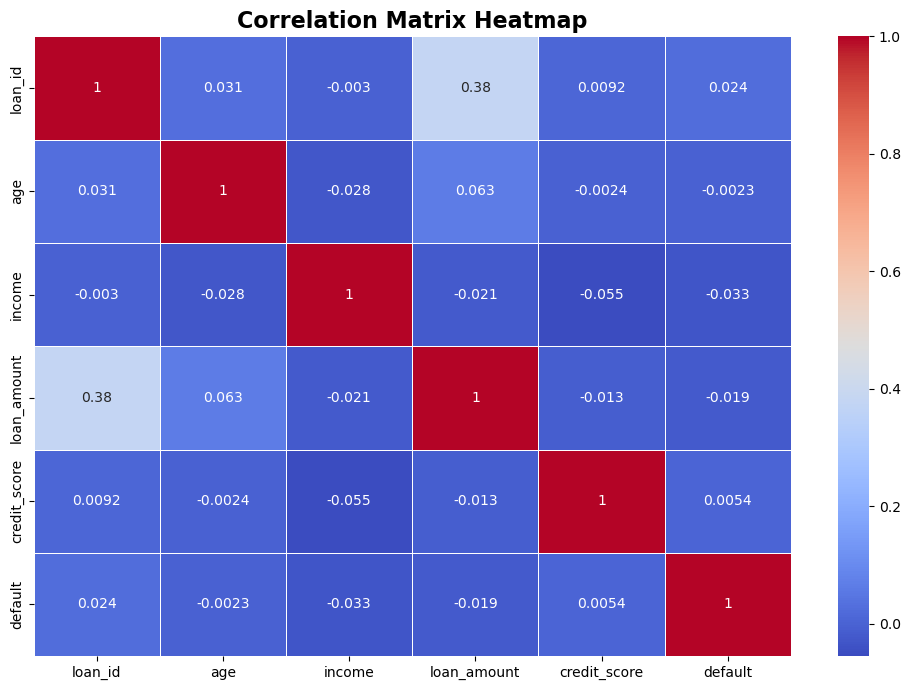

In [7]:
plt.figure(figsize=(10, 7))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Correlation Matrix Heatmap',
          fontsize=16,
          fontweight='bold')

plt.tight_layout()
plt.show()

# Step 3: Outlier Detection

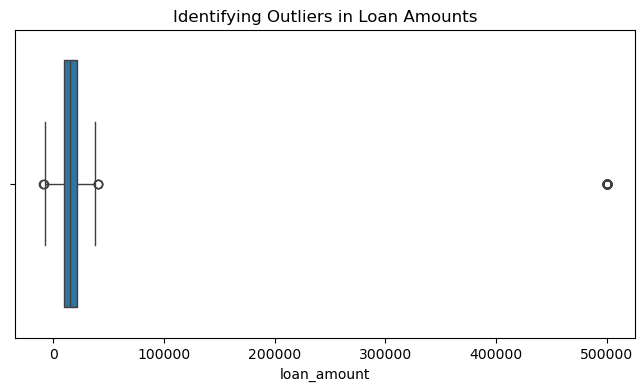

In [8]:
# outlier detection

plt.figure(figsize=(8, 4))

sns.boxplot(x=df['loan_amount'])

plt.title('Identifying Outliers in Loan Amounts')

plt.show()

In [9]:
# Clipping outliers to 5th and 95th percentile
qu_limit = df['loan_amount'].quantile(0.95)
ql_limit = df['loan_amount'].quantile(0.05)

# Create cleaned column
df['loan_amount_cleaned'] = df['loan_amount'].clip(
    upper=qu_limit,
    lower=ql_limit
)

print("Outliers handled using clipping method!")

Outliers handled using clipping method!


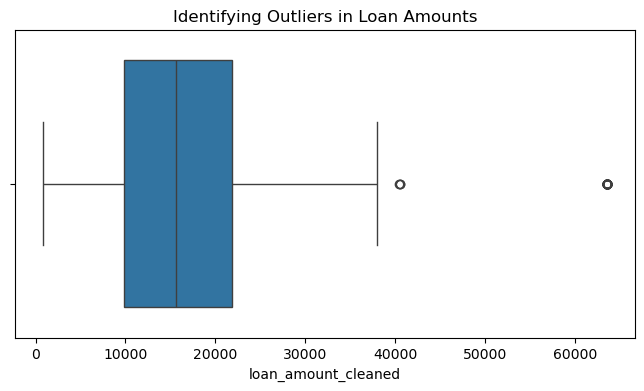

In [10]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['loan_amount_cleaned'])

plt.title('Identifying Outliers in Loan Amounts')

plt.show()

Remaining outliers removed successfully!


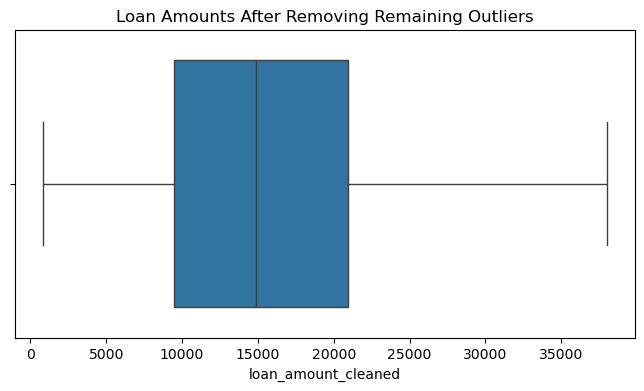

In [11]:
# Remove remaining extreme outliers using IQR Method

Q1 = df['loan_amount_cleaned'].quantile(0.25)
Q3 = df['loan_amount_cleaned'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Keep only normal values
df = df[
    (df['loan_amount_cleaned'] >= lower_bound) &
    (df['loan_amount_cleaned'] <= upper_bound)
]

print("Remaining outliers removed successfully!")

# Boxplot after removing remaining outliers
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['loan_amount_cleaned'])

plt.title('Loan Amounts After Removing Remaining Outliers')

plt.show()

# Step 4: Feature Engineering

In [12]:
# Debt-to-Income Ratio
# Avoid division by zero

df['income'] = df['income'].replace(0, np.nan)

df['dti_ratio'] = df['loan_amount_cleaned'] / df['income']

# Fill any generated NaN values
df['dti_ratio'].fillna(df['dti_ratio'].median(), inplace=True)

In [ ]:
# Categorize credit scores into risk levels
bins = [300, 580, 670, 740, 850]
labels = ['High Risk', 'Fair', 'Good', 'Excellent']

# Create category column
df['risk_category'] = pd.cut(
    df['credit_score'],
    bins=bins,
    labels=labels
)

# Display sample data
print(df[['income',
          'loan_amount_cleaned',
          'dti_ratio',
          'risk_category']].head())

# Step 5: Findings Summary

In [15]:
print("=== FINDINGS SUMMARY ===")

summary = df.groupby('risk_category', observed=False)['default'].mean() * 100

print("Default Percentage by Category:\n")
print(summary)

=== FINDINGS SUMMARY ===
Default Percentage by Category:

risk_category
High Risk    19.472617
Fair         20.805369
Good         20.161290
Excellent    22.222222
Name: default, dtype: float64


# Additional Insights

In [16]:
print("\n=== KEY INSIGHTS ===")

print(f"Average Loan Amount: ${df['loan_amount'].mean():,.2f}")

print(f"Average Income: ${df['income'].mean():,.2f}")

print(f"Average Credit Score: {df['credit_score'].mean():.2f}")

print(f"Highest Risk Category: {summary.idxmax()}")

print(f"Lowest Risk Category: {summary.idxmin()}")


=== KEY INSIGHTS ===
Average Loan Amount: $15,052.38
Average Income: $50,057.85
Average Credit Score: 569.88
Highest Risk Category: Excellent
Lowest Risk Category: High Risk


# Step 6: Project Summary
Project Overview

This project analyzes loan applicant data to understand patterns related to loan defaults and financial risk.

Tasks Performed
1.Loaded and cleaned the dataset.
2.Checked dataset structure and statistics.
3.Handled missing values using the median method.
4.Performed correlation analysis with heatmap visualization.
5.Detected and handled outliers using the clipping method.
6.Created new features such as:
    -Debt-to-Income Ratio
    -Risk Categories
7.Analyzed default percentages across risk groups.
8.Generated insights for better financial decision-making.
Conclusion:
Customers with lower credit scores tend to have higher default rates.
Outlier handling improved the stability of loan amount analysis.
DTI ratio provides additional insight into repayment ability.
Risk categorization helps banks identify high-risk applicants.
Correlation analysis highlights relationships among financial variables.

This analysis can help financial institutions improve loan approval strategies and reduce financial risk.